<a href="https://colab.research.google.com/github/Siddhangana-creator/Siddhangana-creator/blob/main/K_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Importing the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline
import kagglehub
import os
import kagglehub

# Download latest version
path = kagglehub.dataset_download("camnugent/california-housing-prices")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

Using Colab cache for faster access to the 'california-housing-prices' dataset.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


<Axes: xlabel='longitude', ylabel='latitude'>

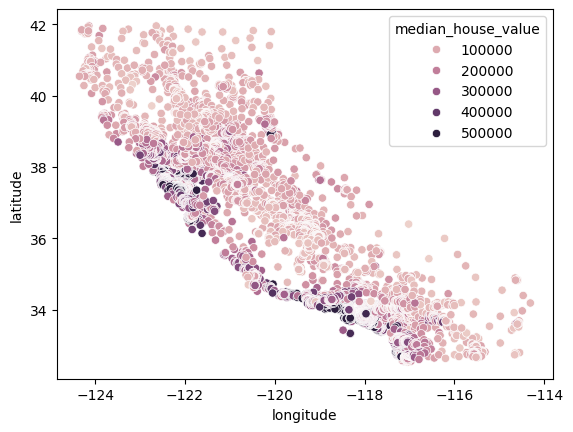

In [ ]:
import seaborn as sns

sns.scatterplot(data = df, x = 'longitude', y = 'latitude', hue = 'median_house_value')

Most of the expensive houses are on the west coast of California with different areas that have clusters of moderately priced houses. This is expected as typically waterfront properties are worth more than houses that are not on the coast.



Determine the optimal number of clusters using the elbow method.

<Axes: >

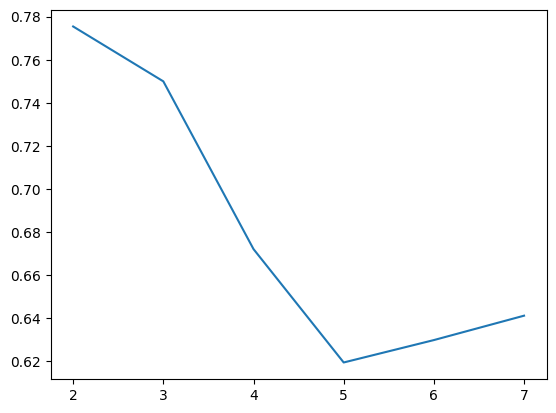

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_score(X_train_norm, kmeans.labels_, metric='euclidean')

K = range(2, 8)
fits = []
score = []


for k in K:
    # train the model for current value of k on training data
    model = KMeans(n_clusters = k, random_state = 0, n_init='auto').fit(X_train_norm)

    # append the model to fits
    fits.append(model)

    # Append the silhouette score to scores
    score.append(silhouette_score(X_train_norm, model.labels_, metric='euclidean'))

sns.lineplot(x = K, y = score)

data are now clearly split into 3 distinct groups


<Axes: xlabel='longitude', ylabel='latitude'>

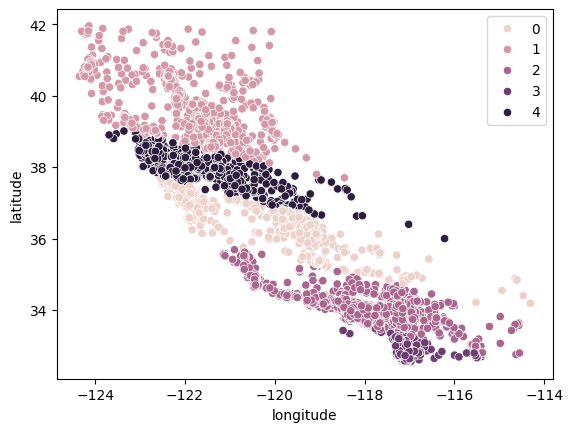

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df[['latitude', 'longitude']], df[['median_house_value']], test_size=0.33, random_state=0)

from sklearn import preprocessing

X_train_norm = preprocessing.normalize(X_train)
X_test_norm = preprocessing.normalize(X_test)

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 5, random_state = 0, n_init='auto')
kmeans.fit(X_train_norm)

#data are now clearly split into 5 distinct groups
print(f"data are now clearly split into 3 distinct groups")
sns.scatterplot(data = X_train, x = 'longitude', y = 'latitude', hue = kmeans.labels_)




Distribution of median house prices in these 5 groups using a boxplot.



<Axes: ylabel='median_house_value'>

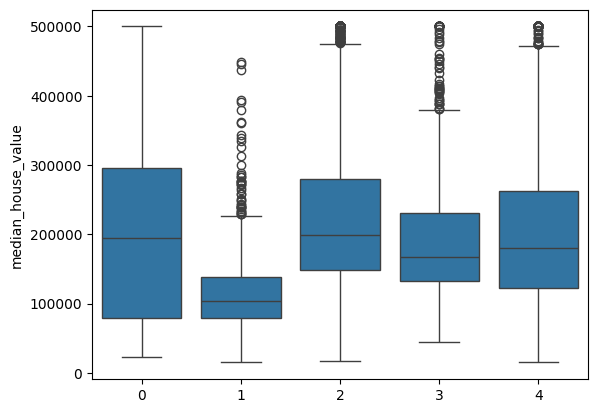

In [ ]:
sns.boxplot(x = kmeans.labels_, y = y_train['median_house_value'])

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_train_norm, kmeans.labels_)
print(f"Silhouette Score: {score:.3f}")

# Try different cluster counts
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=0, n_init='auto')
    km.fit(X_train_norm)
    s = silhouette_score(X_train_norm, km.labels_)
    print(f"k={k}: {s:.3f}")

Silhouette Score: 0.619
k=2: 0.775
k=3: 0.750
k=4: 0.672
k=5: 0.619
k=6: 0.630
k=7: 0.641


Evaluate performance of the clustering algorithm using a Silhouette score which is a part of sklearn.metrics where a lower score represents a better fit.

k=5 was chosen by the elbow method of determinig optimal no. of clusters and since k>0.5 it is a good score


In [ ]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

ch = calinski_harabasz_score(X_train_norm, kmeans.labels_)
db = davies_bouldin_score(X_train_norm, kmeans.labels_)

print(f"Calinski-Harabasz: {ch:.0f}")
print(f"Davies-Bouldin: {db:.3f}")

Calinski-Harabasz: 79371
Davies-Bouldin: 0.537
